# 순환 신경망

## RNN(Recurrent Neural Network)   
※ 참고자료: https://davinci-ai.tistory.com/30
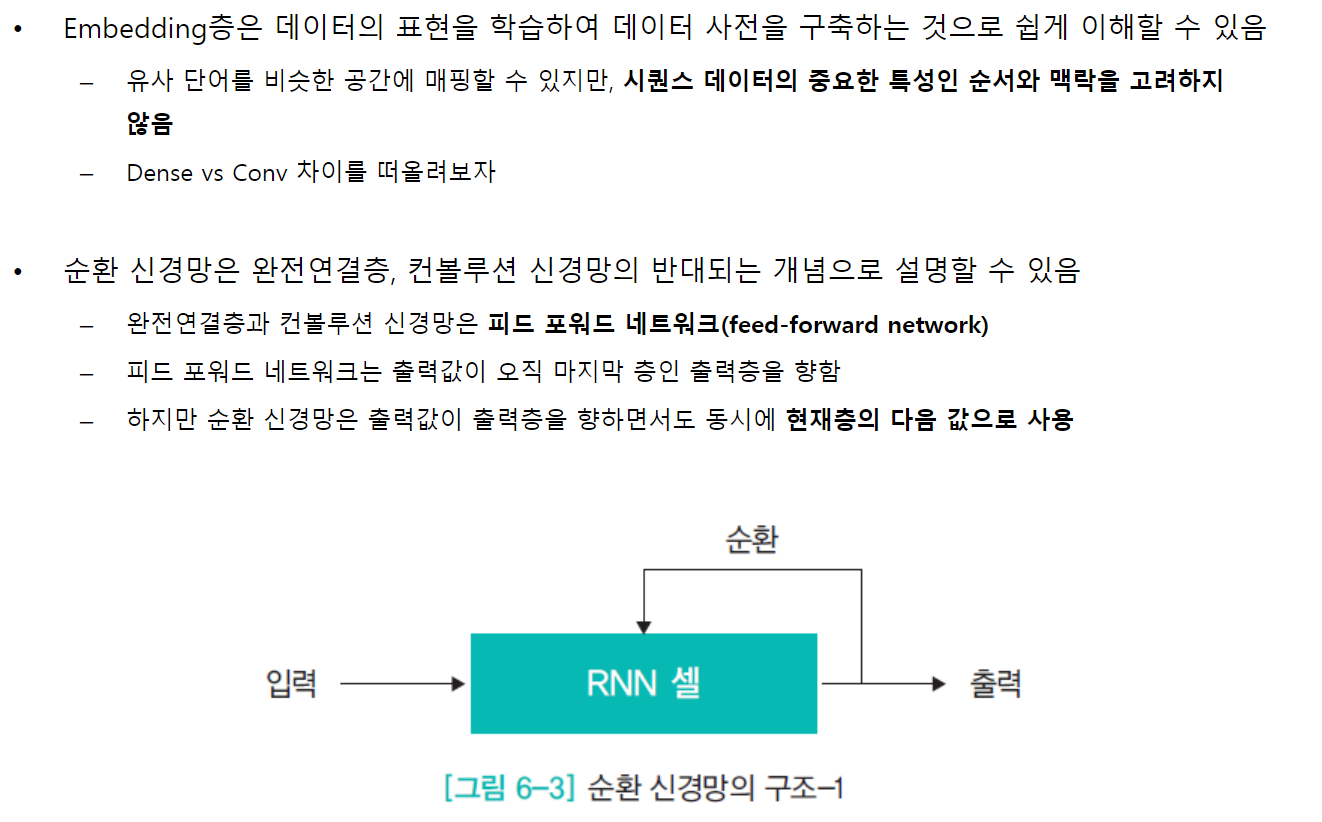

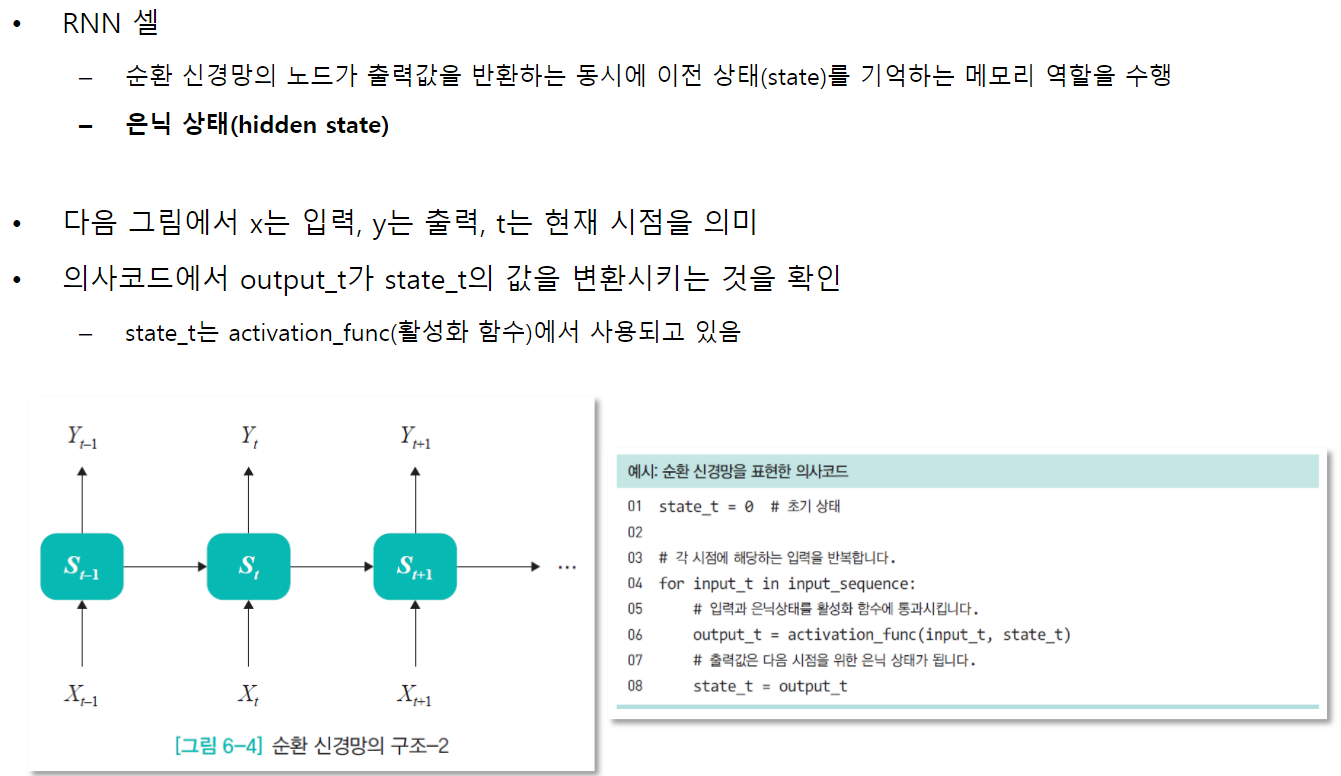

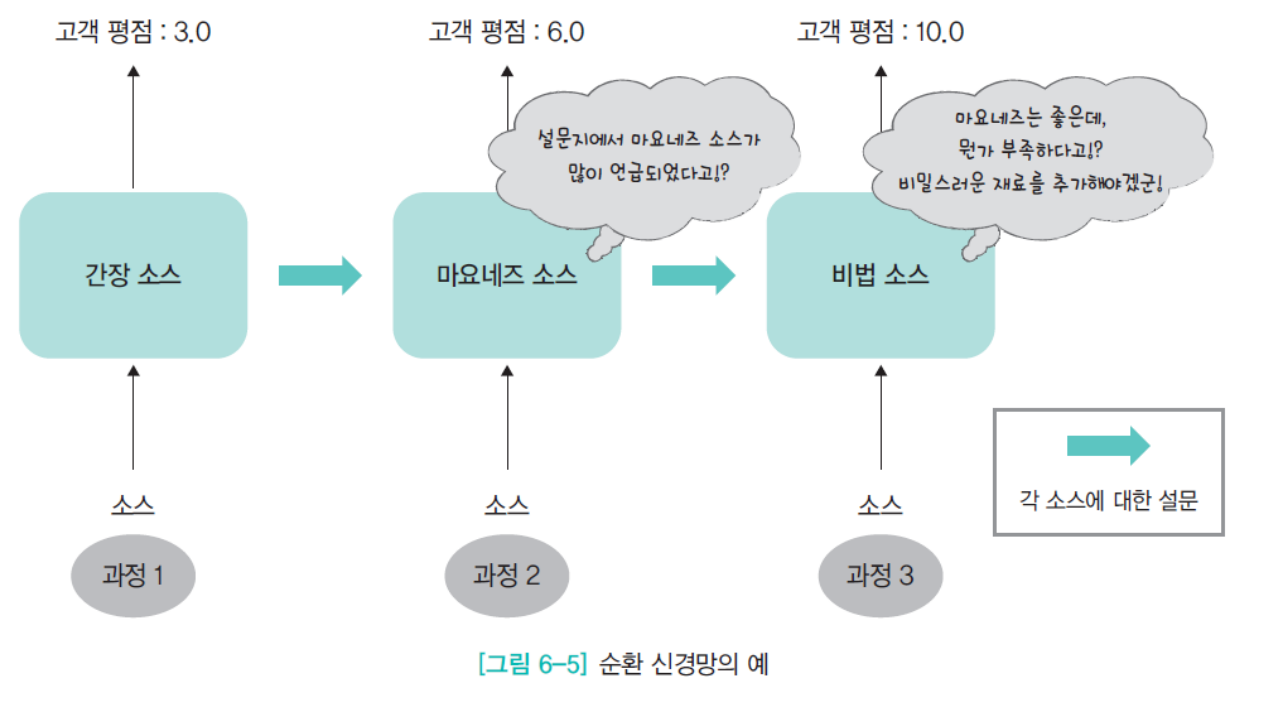

### SimpleRNN을 사용하여 모델 구성하기
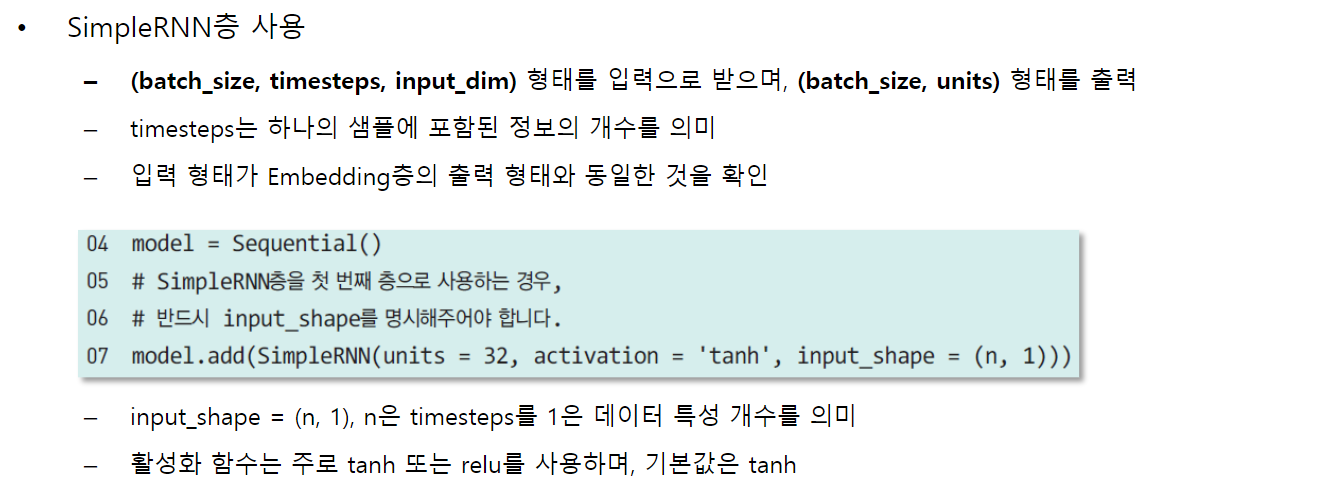

## 네이버 영화 리뷰를 이용한 감성분석(RNN)

In [1]:
import re
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

I0000 00:00:1784699796.082400   55209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784699796.126295   55209 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784699797.146751   55209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


데이터 받아오기(네이버 영화 리뷰)
  - label: 0 => 부정, 1 => 긍정

In [2]:
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_df = pd.read_table(train_url).dropna(subset=["document"])
test_df  = pd.read_table(test_url).dropna(subset=["document"])

display(train_df.head())
display(test_df.head())

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


X_train, y_train, X_test, y_test 데이터 생성

In [3]:
X_train = train_df["document"].astype(str).tolist()
y_train = train_df["label"].values

X_train[:5]

['아 더빙.. 진짜 짜증나네요 목소리',
 '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나',
 '너무재밓었다그래서보는것을추천한다',
 '교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정',
 '사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다']

In [4]:
X_test = test_df["document"].astype(str).tolist()
y_test = test_df["label"].values

- 데이터 정제

In [5]:
def clean_text(text):
  txt = re.sub(r"[^가-힣a-zA-Z]", " ", text)
  txt = re.sub(r"\s+", " ", txt).strip()
  return txt

train_txt = [clean_text(text) for text in X_train]
test_txt  = [clean_text(text) for text in X_test]

train_txt[:5]

['아 더빙 진짜 짜증나네요 목소리',
 '흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나',
 '너무재밓었다그래서보는것을추천한다',
 '교도소 이야기구먼 솔직히 재미는 없다 평점 조정',
 '사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다']

토큰화 및 단어사전 생성 => 정수 인코딩

In [6]:
vocab_size = 20000

tokenize = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenize.fit_on_texts(train_txt)

In [7]:
x_train = tokenize.texts_to_sequences(train_txt)
x_test  = tokenize.texts_to_sequences(test_txt)

x_train[0]

[24, 912, 5, 6735, 1101]

모든 문장의 길이 맞추기(Pandding)

In [8]:
max_len = 100

x_train = pad_sequences(x_train, maxlen=max_len, padding='post')
x_test  = pad_sequences(x_test, maxlen=max_len, padding='post')

In [9]:
x_train[0]

array([  24,  912,    5, 6735, 1101,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0], dtype=int32)

학습데이터/검증데이터 분리

In [10]:
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train,
                                            test_size=0.2,
                                            random_state=42)

x_tr.shape, x_val.shape

((119996, 100), (29999, 100))

### 모델 구성

In [11]:
tf.random.set_seed(42)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    SimpleRNN(64),          # RNN 핵심 레이어
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # 이진분류
])

/home/dmin/miniconda3/envs/pytorchedu/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784699804.830681   55209 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [12]:
model.compile(optimizer='adam',
              loss = 'binary_crossentropy',
              metrics = ['acc'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 모델 학습시키기

In [13]:
# 강제 종료
es = EarlyStopping(monitor="val_loss",
                   patience=10,
                   restore_best_weights=True)   # 종료후 가장 좋은 가중치 복원

# 최적의 가중치 자동 저장
cp = ModelCheckpoint("./model/SRNN.h5",
                     monitor="val_loss",
                     save_best_only=True)

In [14]:
history = model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[es, cp],
    verbose=1
)

Epoch 1/30


I0000 00:00:1784699806.283402   56649 service.cc:153] XLA service 0x7fca74031270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784699806.283428   56649 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1784699806.306159   56649 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784699806.447028   56649 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1784699806.486710   56649 dot_merger.cc:481] Merging Dots in computation: sequential_1_simple_rnn_1_while_body_1574_grad_1844_const_0__.18.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1784699806.767118   56649 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set

  7/469 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - acc: 0.4939 - loss: 0.6972 

I0000 00:00:1784699808.723645   56649 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.5927 - loss: 0.6673

...

469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - acc: 0.6834 - loss: 0.6065 - val_acc: 0.6614 - val_loss: 0.6138
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - acc: 0.6860 - loss: 0.5911 - val_acc: 0.6571 - val_loss: 0.6318
Epoch 4/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.7293 - loss: 0.5481

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - acc: 0.7295 - loss: 0.5479 - val_acc: 0.6856 - val_loss: 0.6021
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.7503 - loss: 0.5132 - val_acc: 0.6873 - val_loss: 0.6062
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.7353 - loss: 0.5368 - val_acc: 0.6907 - val_loss: 0.6059
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - acc: 0.7729 - loss: 0.4762 - val_acc: 0.6909 - val_loss: 0.6038
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.7664 - loss: 0.4830 - val_acc: 0.5101 - val_loss: 0.7222
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.6453 - loss: 0.6289 - val_acc: 0.6696 - val_loss: 0.6180
Epoch 10/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.7503 - loss: 0.5281 - val_acc: 0.6961 - val_loss: 0.6158
Epoch 11/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.7733 - loss: 0.4964

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - acc: 0.7733 - loss: 0.4964 - val_acc: 0.7053 - val_loss: 0.5999
Epoch 12/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.7949 - loss: 0.4615 - val_acc: 0.7074 - val_loss: 0.6092
Epoch 13/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.7603 - loss: 0.5005 - val_acc: 0.5850 - val_loss: 0.6768
Epoch 14/30
416/469 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.7354 - loss: 0.5430

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - acc: 0.7414 - loss: 0.5346 - val_acc: 0.7243 - val_loss: 0.5555
Epoch 15/30
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.8195 - loss: 0.4063

469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - acc: 0.8195 - loss: 0.4062 - val_acc: 0.7549 - val_loss: 0.5301
Epoch 16/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - acc: 0.8385 - loss: 0.3674 - val_acc: 0.7510 - val_loss: 0.5413
Epoch 17/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.8496 - loss: 0.3364 - val_acc: 0.7559 - val_loss: 0.5517
Epoch 18/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - acc: 0.8632 - loss: 0.3060 - val_acc: 0.7598 - val_loss: 0.5568
Epoch 19/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.8740 - loss: 0.2822 - val_acc: 0.7586 - val_loss: 0.5742
Epoch 20/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - acc: 0.8782 - loss: 0.2703 - val_acc: 0.7634 - val_loss: 0.5772
Epoch 21/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - acc: 0.8823 - loss: 0.2601 - val_acc: 0.7438 - val_loss: 0.6135
Epoch 22/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - acc: 0.8896 - loss: 0.2433 - val_acc: 0.7383 - val_loss: 0.6494
Epoch 23/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/ste

### 예측 결과 그려보기

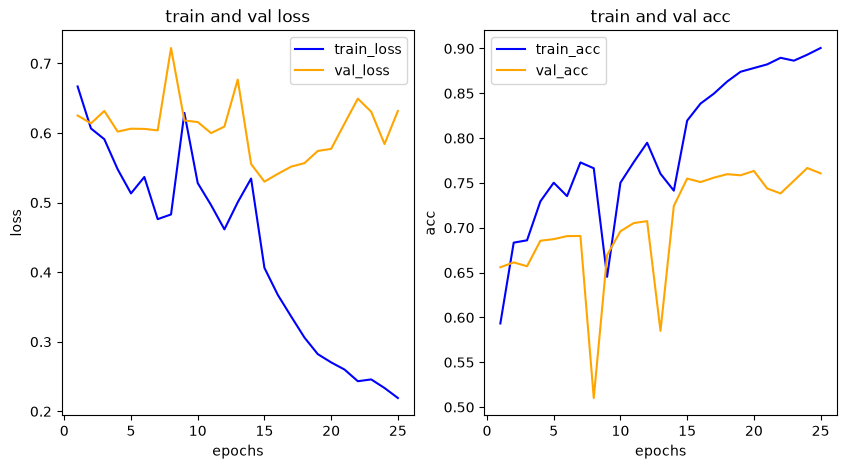

In [15]:
import matplotlib.pyplot as plt

his_dict = history.history
loss = his_dict['loss']
val_loss = his_dict['val_loss']

epochs = range(1, len(loss) + 1)
fig = plt.figure(figsize = (10, 5))

# 훈련 및 검증 손실 그리기
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color = 'blue', label = 'train_loss')
ax1.plot(epochs, val_loss, color = 'orange', label = 'val_loss')
ax1.set_title('train and val loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('loss')
ax1.legend()

acc = his_dict['acc']
val_acc = his_dict['val_acc']

# 훈련 및 검증 정확도 그리기
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color = 'blue', label = 'train_acc')
ax2.plot(epochs, val_acc, color = 'orange', label = 'val_acc')
ax2.set_title('train and val acc')
ax2.set_xlabel('epochs')
ax2.set_ylabel('acc')
ax2.legend()

plt.show()

### 평가

In [16]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"NSMC Test Loss: {loss:.4f}, Test Acc: {acc:.4f}")

I0000 00:00:1784700033.634713   56648 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1784700033.946276   59414 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 12 bytes spill stores, 12 bytes spill loads



NSMC Test Loss: 0.5317, Test Acc: 0.7522


### 새로운 문장 예측

In [17]:
def predict_sentiment_kor(text: str):
    text = clean_text(text)
    seq = tokenize.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = float(model.predict(seq, verbose=0)[0][0])
    label = "긍정" if prob >= 0.5 else "부정"
    print(f"[{label}] prob={prob:.3f} | {text}")

In [18]:
predict_sentiment_kor("연기가 너무 좋고 스토리도 감동적이었어요!!!!!!!")
predict_sentiment_kor("지루하고 시간 아까운 영화였습니다")

[긍정] prob=0.922 | 연기가 너무 좋고 스토리도 감동적이었어요
[부정] prob=0.036 | 지루하고 시간 아까운 영화였습니다


In [19]:
import joblib

joblib.dump(tokenize, "tokenizer.joblib")

['tokenizer.joblib']